In [14]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## **1. Load and Preprocess the MNIST Dataset**

In [2]:
(x_train_data, y_train_data), (x_val_data, y_val_data) = keras.datasets.mnist.load_data()

In [3]:
def preprocessing_function(x_new, y_new):
  x_new = tf.cast(x_new, tf.float32) / 255.0  # Normalize pixel values
  y_new = tf.cast(y_new, tf.int64)            # Convert labels to integers
  return x_new, y_new

def func_creating_dataset(xs_data, ys_data, num_classes=10):
  ys_data = tf.one_hot(ys_data, depth=num_classes)  # One-hot encode labels
  return tf.data.Dataset.from_tensor_slices((xs_data, ys_data)) \
    .map(preprocessing_function) \
    .shuffle(buffer_size=1000) \
    .batch(32)

# Create the training and validation datasets using func_creating_dataset
dataset_training = func_creating_dataset(x_train_data, y_train_data) # Creating the training dataset
dataset_val = func_creating_dataset(x_val_data, y_val_data)       # Creating the validation dataset

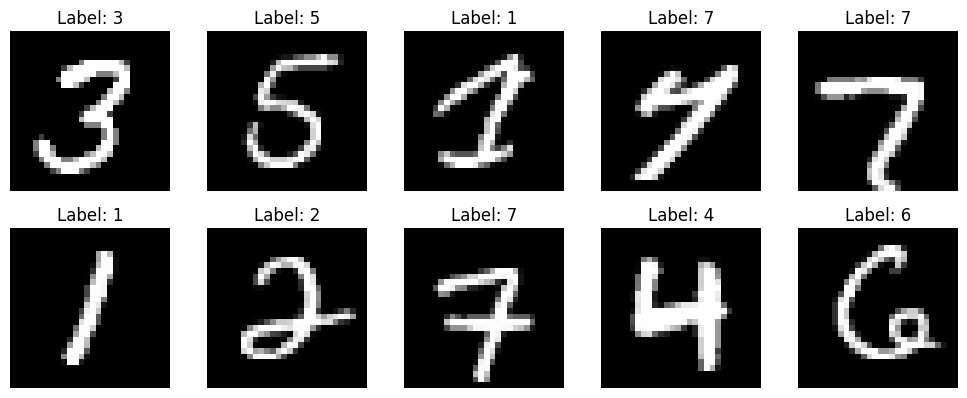

In [4]:
plt.figure(figsize=(10, 10))
# Create an unbatched version of the dataset for visualization
unbatched_dataset_training = dataset_training.unbatch()

# Take 25 individual images from the unbatched dataset
for i, (image, label) in enumerate(unbatched_dataset_training.take(10)):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(image.numpy().squeeze(), cmap='gray')
    plt.title(f"Label: {label.numpy().argmax()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## **2. Build a Fully Connected Neural Network**

In [23]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape = (28,28)),
    keras.layers.Dense(256,activation='relu'),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# To-Do: compile the model with adam, categorical_crossentropy, and accuracy
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

## **3. Train the Neural Network**

In [25]:
# To-Do: train then evaluate
history = model.fit(dataset_training, epochs=10, validation_data=dataset_val)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9402 - loss: 0.2024 - val_accuracy: 0.9694 - val_loss: 0.1007
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.9744 - loss: 0.0836 - val_accuracy: 0.9784 - val_loss: 0.0669
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9816 - loss: 0.0576 - val_accuracy: 0.9858 - val_loss: 0.0437
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9855 - loss: 0.0442 - val_accuracy: 0.9891 - val_loss: 0.0330
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9893 - loss: 0.0337 - val_accuracy: 0.9872 - val_loss: 0.0397
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9914 - loss: 0.0258 - val_accuracy: 0.9922 - val_loss: 0.0216
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - accuracy: 0.9912 - loss: 0.0258 - val_accuracy: 0.9929 - val_loss: 0.0204
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9940 -

In [26]:
pred_mnist = model.predict(dataset_val)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


## **4. Evaluate the Model’s Performance**

In [27]:
test_loss, test_accuracy = model.evaluate(dataset_val)
print(f"Test Loss: {round(test_loss,3)}, Test Accuracy: {round(test_accuracy,3)}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9763 - loss: 0.1155
Test Loss: 0.115, Test Accuracy: 0.976


<Figure size 1000x1000 with 0 Axes>

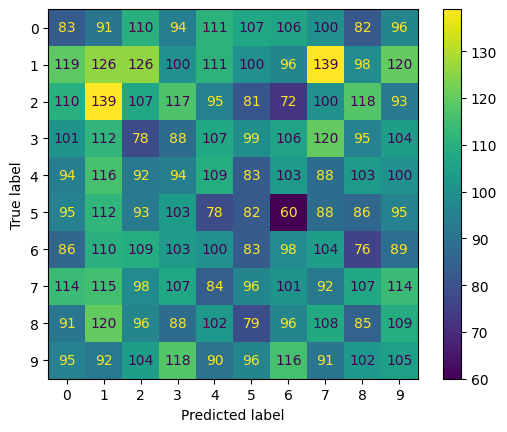

In [28]:
plt.figure(figsize=(10, 10), dpi=100)
ConfusionMatrixDisplay.from_predictions(y_val_data, pred_mnist.argmax(axis=1))
plt.show()

Le modèle ne distinque pas les chiffres 8, 0, 7, 3